# Antiviral Potency Prediction — Final Submission
**Author:** Nishant Chaudhari | **Group:** XN
**Dataset:** `asap-discovery/antiviral-potency-2025-unblinded` (Polaris Hub)
**Target:** SARS-CoV-2 Mpro pIC50
**External Test Set:** Cresset OEZ — 76 compounds

---

## Pipeline Summary

**Data**
- Loaded the ASAP Discovery antiviral potency dataset (1,328 molecules, 2 targets) via the Polaris client
- Dropped molecules with no label for either target, retaining all partially-labeled rows
- Focused on SARS-CoV-2 Mpro pIC50 (1,105 labeled molecules, range 4.00–8.73)

**Molecular Representation**
- ECFP Morgan fingerprints generated with RDKit `MorganGenerator` API (radius=5, 4096 bits)
- Parameters match the OpenEye GraphSim toolkit default (max radius 5, 4096 bits)
- No feature scaling applied — tree-based models do not require it

**Models**
- **Random Forest** (n\_estimators=200) — ensemble baseline, robust on sparse high-dimensional inputs
- **XGBoost** (n\_estimators=200, lr=0.05, max\_depth=6) — gradient boosting with regularization
- Both models evaluated via 5-fold cross-validation using a single `cross_validate` call (R² and RMSE)
- Final models refit on full labeled training data for external inference

**External Test Set Inference**
- 76-compound Cresset test set provided in OpenEye `.oez` binary format
- Parsed without OpenEye toolkit: libzstd (via ctypes) decompresses 76 zstd frames; RDKit reconstructs SMILES from Kekulé atom/bond table
- Predictions and evaluation saved to `test_predictions.csv`

## 0. Imports & Setup

In [1]:
import ctypes
import ctypes.util
import re
import numpy as np
import pandas as pd
import polaris as po
from rdkit import Chem
from rdkit.Chem import RWMol
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import r2_score, root_mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

c:\Users\Nishant\Anaconda3\envs\openeye\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset Loading & Basic Exploration

In [2]:
DATASET_SLUG = "asap-discovery/antiviral-potency-2025-unblinded"

TARGET_SARS = "pIC50 (SARS-CoV-2 Mpro)"
TARGET_MERS = "pIC50 (MERS-CoV Mpro)"
SMILES_COL  = "CXSMILES"

dataset = po.load_dataset(DATASET_SLUG)
df_raw = pd.DataFrame(dataset[:])

print(f"Dataset : {DATASET_SLUG}")
print(f"Raw shape: {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")

[2026-04-12 22:47:35] INFO     The version of Polaris that was used to create the artifact          _artifact.py:96
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.13.1.dev3+g4dd22f132).                              

                      WARNING  You're loading data from a remote location. If the dataset is small     _base.py:187
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[22:47:36]  Success: Fetching dataset                                                                 context.py:53

Dataset : asap-discovery/antiviral-potency-2025-unblinded
Raw shape: (1328, 5)
Columns : ['CXSMILES', 'Molecule Name', 'Set', 'pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']


In [3]:
# Drop rows that have no label for EITHER target (unlabeled molecules)
df = df_raw.dropna(subset=[TARGET_SARS, TARGET_MERS], how='all').reset_index(drop=True)

print(f"Rows before dropping fully unlabeled : {len(df_raw)}")
print(f"Rows after  dropping fully unlabeled : {len(df)}")
print(f"Rows removed                         : {len(df_raw) - len(df)}")
print()
print("Missing values per column (remaining dataset):")
print(df[[TARGET_SARS, TARGET_MERS]].isnull().sum().to_string())

Rows before dropping fully unlabeled : 1328
Rows after  dropping fully unlabeled : 1328
Rows removed                         : 0

Missing values per column (remaining dataset):
pIC50 (SARS-CoV-2 Mpro)    223
pIC50 (MERS-CoV Mpro)      130


In [4]:
df.head(3)

,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
0,COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...,ASAP-0000141,Train,4.19,NaN
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
2,CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...,ASAP-0000143,Train,4.73,NaN


In [5]:
print(f"--- {TARGET_SARS} ---")
print(df[TARGET_SARS].describe())
print()
print(f"--- {TARGET_MERS} ---")
print(df[TARGET_MERS].describe())

--- pIC50 (SARS-CoV-2 Mpro) ---
count    1105.000000
mean        5.543620
std         1.165263
min         4.000000
25%         4.570000
50%         5.230000
75%         6.370000
max         8.730000
Name: pIC50 (SARS-CoV-2 Mpro), dtype: float64

--- pIC50 (MERS-CoV Mpro) ---
count    1198.000000
mean        4.914023
std         0.948339
min         1.000000
25%         4.270000
50%         4.625000
75%         5.410000
max         9.000000
Name: pIC50 (MERS-CoV Mpro), dtype: float64


## 2. Molecular Feature Generation — Morgan Fingerprints

Morgan fingerprints with **radius=5** and **4096 bits** — matching the GraphSim toolkit default
(max radius 5, 4096 bits). Uses the modern RDKit `MorganGenerator` API.

In [6]:
RADIUS = 5
N_BITS = 4096

morgan_gen = GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

def smiles_to_morgan(smi: str) -> np.ndarray | None:
    """Convert a SMILES string to a Morgan fingerprint numpy array.
    Returns None if the SMILES cannot be parsed.
    """
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)


fps, valid_idx = [], []
for i, smi in enumerate(df[SMILES_COL]):
    fp = smiles_to_morgan(smi)
    if fp is not None:
        fps.append(fp)
        valid_idx.append(i)

X        = np.array(fps, dtype=np.uint8)
df_valid = df.iloc[valid_idx].reset_index(drop=True)

print(f"Featurized molecules : {len(X)} / {len(df)}")
print(f"Feature matrix shape : {X.shape}  (molecules x fingerprint bits)")

Featurized molecules : 1328 / 1328
Feature matrix shape : (1328, 4096)  (molecules x fingerprint bits)


## 3. Exploratory Analysis

In [7]:
bit_freq = X.mean(axis=0)
print(f"Mean bit-on rate : {bit_freq.mean():.4f}")
print(f"Max  bit-on rate : {bit_freq.max():.4f}  (most common structural feature)")
print(f"Min  bit-on rate : {bit_freq.min():.4f}  (rarest structural feature)")

Mean bit-on rate : 0.0230
Max  bit-on rate : 1.0000  (most common structural feature)
Min  bit-on rate : 0.0000  (rarest structural feature)


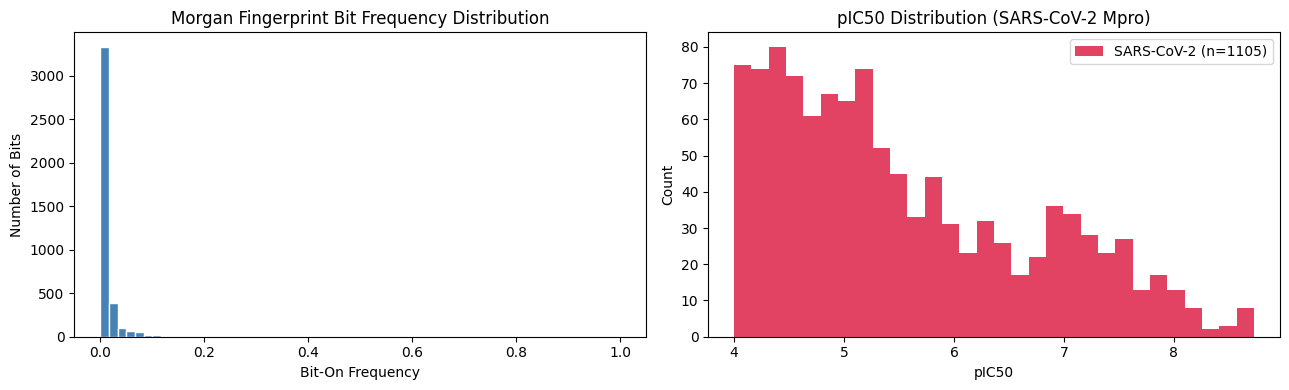

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bit_freq, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Bit-On Frequency')
axes[0].set_ylabel('Number of Bits')
axes[0].set_title('Morgan Fingerprint Bit Frequency Distribution')

sars_vals = df_valid[TARGET_SARS].dropna().astype(float)

axes[1].hist(sars_vals, bins=30, alpha=0.8, color='crimson',
             label=f'SARS-CoV-2 (n={len(sars_vals)})')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Count')
axes[1].set_title('pIC50 Distribution (SARS-CoV-2 Mpro)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Model Training & Cross-Validation

Two models are trained on **SARS-CoV-2 Mpro** only (per advisor feedback):
- **Random Forest** — ensemble baseline, handles sparse high-dimensional inputs well
- **XGBoost** — sequential boosting with regularization, stronger on tabular data

NaN labels are masked before training. `cross_validate` is used with both R2 and RMSE
in a **single CV pass** (avoids running CV twice).

In [9]:
CV_FOLDS = 5
SCORING  = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}
kf       = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'      : XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, n_jobs=-1, verbosity=0),
}

# results[model_name] = {'r2': ..., 'rmse': ..., 'fitted_model': ...}
results = {}

y_raw = df_valid[TARGET_SARS].values.astype(float)
mask  = ~np.isnan(y_raw)
X_t   = X[mask]
y_t   = y_raw[mask]

print(f"{'='*60}")
print(f"Target : {TARGET_SARS}")
print(f"  Labeled samples : {mask.sum()}")
print(f"  pIC50 range     : {y_t.min():.2f} - {y_t.max():.2f}")
print(f"{'='*60}")

for model_name, model in models.items():
    cv_out = cross_validate(model, X_t, y_t, cv=kf,
                            scoring=SCORING, return_estimator=True)

    r2_scores   =  cv_out['test_r2']
    rmse_scores = -cv_out['test_rmse']

    print(f"\n  [{model_name}]")
    print(f"    5-Fold CV R2   : {r2_scores.mean():.4f} +/- {r2_scores.std():.4f}")
    print(f"    5-Fold CV RMSE : {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}")

    # Refit on full labeled data for downstream use
    fitted_model = type(model)(**model.get_params())
    fitted_model.fit(X_t, y_t)

    results[model_name] = {
        'r2'          : r2_scores,
        'rmse'        : rmse_scores,
        'fitted_model': fitted_model,
    }

Target : pIC50 (SARS-CoV-2 Mpro)
  Labeled samples : 1105
  pIC50 range     : 4.00 - 8.73

  [Random Forest]
    5-Fold CV R2   : 0.6411 +/- 0.0428
    5-Fold CV RMSE : 0.6910 +/- 0.0326

  [XGBoost]
    5-Fold CV R2   : 0.6372 +/- 0.0454
    5-Fold CV RMSE : 0.6945 +/- 0.0339


## 5. RF Feature Importance Visualization

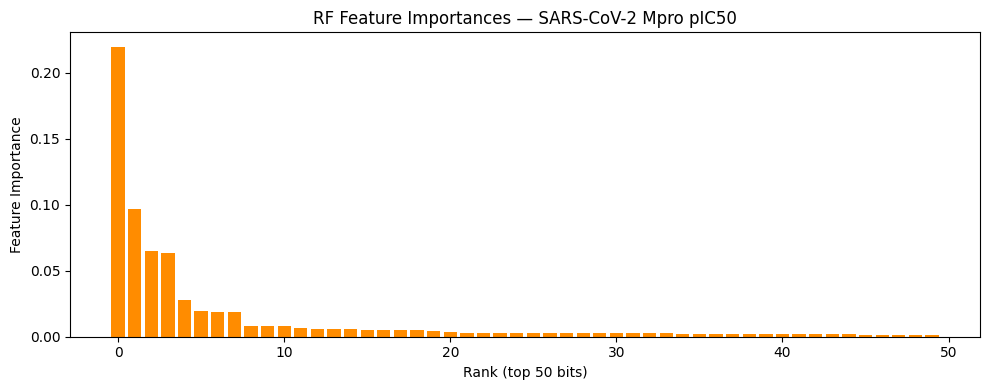

In [10]:
rf_model = results['Random Forest']['fitted_model']
top50    = np.argsort(rf_model.feature_importances_)[::-1][:50]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(50), rf_model.feature_importances_[top50], color='darkorange')
ax.set_xlabel('Rank (top 50 bits)')
ax.set_ylabel('Feature Importance')
ax.set_title('RF Feature Importances — SARS-CoV-2 Mpro pIC50')
plt.tight_layout()
plt.show()

## 6. Test Set Inference — Cresset OEZ File

The `.oez` file is OpenEye's proprietary binary format: a 3-byte magic header followed by
76 independent zstd-compressed frames, one per molecule. Each frame contains the molecule
in OE's internal binary encoding (atom symbols + bond table + 3D coordinates) plus SD-style
tagged properties (pIC50, molecule name).

We parse it with **pure Python + libzstd (via ctypes) + RDKit** — no OpenEye license required.

In [11]:
OEZ_PATH = "Cresset_OE_Mpro_76cmpds.oez"  # update path if needed

# ── 1. Load libzstd ──────────────────────────────────────────────────────────
_libzstd = ctypes.CDLL(ctypes.util.find_library('zstd'))
_libzstd.ZSTD_findFrameCompressedSize.restype  = ctypes.c_size_t
_libzstd.ZSTD_findFrameCompressedSize.argtypes = [ctypes.c_void_p, ctypes.c_size_t]
_libzstd.ZSTD_decompressStream.restype         = ctypes.c_size_t
_libzstd.ZSTD_createDStream.restype            = ctypes.c_void_p
_libzstd.ZSTD_initDStream.argtypes             = [ctypes.c_void_p]
_libzstd.ZSTD_freeDStream.argtypes             = [ctypes.c_void_p]
_libzstd.ZSTD_decompressStream.argtypes        = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_void_p]

class _InBuf(ctypes.Structure):
    _fields_ = [('src', ctypes.c_void_p), ('size', ctypes.c_size_t), ('pos', ctypes.c_size_t)]
class _OutBuf(ctypes.Structure):
    _fields_ = [('dst', ctypes.c_void_p), ('size', ctypes.c_size_t), ('pos', ctypes.c_size_t)]

def _decode_zstd_frame(raw: bytes, start: int) -> bytes:
    """Decompress one zstd frame from `raw` beginning at byte `start`."""
    remaining = raw[start:]
    c_in   = (ctypes.c_char * len(remaining)).from_buffer_copy(remaining)
    fsize  = _libzstd.ZSTD_findFrameCompressedSize(ctypes.addressof(c_in), len(remaining))
    frame  = raw[start : start + fsize]
    c_fr   = (ctypes.c_char * len(frame)).from_buffer_copy(frame)
    out_sz = 2 * 1024 * 1024
    c_out  = (ctypes.c_char * out_sz)()
    ib = _InBuf(ctypes.addressof(c_fr),  len(frame), 0)
    ob = _OutBuf(ctypes.addressof(c_out), out_sz,    0)
    ds = _libzstd.ZSTD_createDStream()
    _libzstd.ZSTD_initDStream(ds)
    _libzstd.ZSTD_decompressStream(ds, ctypes.byref(ob), ctypes.byref(ib))
    _libzstd.ZSTD_freeDStream(ds)
    return bytes(c_out[:ob.pos])

# ── 2. Locate all zstd frames (one per molecule) ─────────────────────────────
with open(OEZ_PATH, 'rb') as fh:
    raw = fh.read()

ZSTD_MAGIC = bytes([0x28, 0xB5, 0x2F, 0xFD])
frame_starts = []
pos = 0
while True:
    idx = raw.find(ZSTD_MAGIC, pos)
    if idx == -1:
        break
    frame_starts.append(idx)
    pos = idx + 1

print(f"OEZ frames found : {len(frame_starts)}")

# ── 3. Decode every frame ────────────────────────────────────────────────────
decoded_frames = [_decode_zstd_frame(raw, s) for s in frame_starts]
print(f"Frames decoded   : {len(decoded_frames)}")

OEZ frames found : 76
Frames decoded   : 76


In [12]:
# ── 4. Parse each frame -> SMILES + pIC50 + name ─────────────────────────────

_ATOM_CHARS = set(b'cCnNoOsSfFpPbBiI[]@H+-0123456789lrsu')

# OEZ stores Kekule form: 0xc1 = single bond in aromatic ring,
# 0xc2 = double bond in aromatic ring. Let RDKit perceive aromaticity.
_BOND_TYPE = {
    0x01: Chem.BondType.SINGLE,
    0x02: Chem.BondType.DOUBLE,
    0xc1: Chem.BondType.SINGLE,
    0xc2: Chem.BondType.DOUBLE,
}

def _parse_atom_str(s: str):
    """Return list of element symbols from OEZ atom string."""
    atoms, i = [], 0
    while i < len(s):
        ch = s[i]
        if ch == '[':
            j = s.index(']', i)
            inner = s[i+1:j].strip('H+-@0123456789')
            atoms.append(inner.capitalize())
            i = j + 1
        elif ch in ('C', 'B') and i+1 < len(s) and s[i+1] in ('l', 'r'):
            atoms.append(ch + s[i+1]);  i += 2
        elif ch == 'H':
            atoms.append('H');           i += 1
        elif ch.islower():
            atoms.append(ch.upper());    i += 1
        elif ch.isupper():
            atoms.append(ch);            i += 1
        else:
            i += 1
    return atoms

def _parse_bonds(data: bytes):
    bonds, i = [], 0
    while i + 2 < len(data):
        a1, a2, bt = data[i], data[i+1], data[i+2]
        if bt not in _BOND_TYPE:
            break
        bonds.append((a1, a2, _BOND_TYPE[bt]))
        i += 3
    return bonds

def frame_to_record(data: bytes) -> dict:
    """Parse one OEZ frame -> {'SMILES', 'pIC50_measured', 'Name'}."""
    # --- atom string (starts at byte 7) ---
    start = 7
    end   = start
    while end < len(data) and data[end] in _ATOM_CHARS:
        end += 1
    atom_str = data[start:end].decode()

    # --- bond table (after 0xbe separator) ---
    try:
        be_pos = data.index(b'\xbe', end)
    except ValueError:
        be_pos = end
    bonds = _parse_bonds(data[be_pos + 1:])

    # --- pIC50 ---
    pic50 = None
    pi = data.find(b'pIC50')
    if pi != -1:
        m = re.match(rb'([\d.]+)', data[pi + 6 : pi + 22])
        if m:
            pic50 = float(m.group(1))

    # --- molecule name (last meaningful printable string) ---
    name = ''
    for nm in reversed(list(re.finditer(rb'[ -~]{3,}', data))):
        s = nm.group().decode('ascii', errors='replace').strip()
        if s and 'pIC50' not in s and not re.match(r'^[\d.eE+\-]+$', s):
            if not all(c in 'cCnNoOsSfFpPbBiI[]@H+-0123456789lr ' for c in s):
                name = s;  break

    # --- build RDKit mol from heavy atoms + bonds ---
    atoms = _parse_atom_str(atom_str)
    heavy = [(i, e) for i, e in enumerate(atoms) if e != 'H']
    h_set = {i for i, _ in heavy}
    h_map = {old: new for new, (old, _) in enumerate(heavy)}

    rwmol = RWMol()
    for _, elem in heavy:
        rwmol.AddAtom(Chem.Atom(elem))

    for a1, a2, btype in bonds:
        if a1 in h_map and a2 in h_map:
            try:
                rwmol.AddBond(h_map[a1], h_map[a2], btype)
            except Exception:
                pass

    smi = None
    try:
        mol = rwmol.GetMol()
        Chem.SanitizeMol(mol)
        smi = Chem.MolToSmiles(mol)
    except Exception:
        pass

    return {'SMILES': smi, 'pIC50_measured': pic50, 'Name': name}


records = [frame_to_record(f) for f in decoded_frames]
df_test = pd.DataFrame(records)

n_smi   = df_test['SMILES'].notna().sum()
n_pic50 = df_test['pIC50_measured'].notna().sum()
print(f"Test set molecules  : {len(df_test)}")
print(f"SMILES parsed OK    : {n_smi}")
print(f"With pIC50 label    : {n_pic50}")
print()
df_test.head()

Test set molecules  : 76
SMILES parsed OK    : 76
With pIC50 label    : 76



,SMILES,pIC50_measured,Name
0,O=c1[nH]cc(-c2cc(-c3cc(Cl)cc(OCCc4ccccc4)c3)c(...,6.96,A YTM 401_St15
1,Cn1cc(-c2cc(-c3cc(Cl)c(F)c(OCc4ccccc4Cl)c3)c(=...,7.36,19 (1)_19MCL
2,C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.N.N....,5.00,19_Patent19
3,C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C....,6.77,A XFD 400_CS26
4,C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C.C....,7.21,16 (1)_16MCL


In [13]:
# Featurize test molecules using the same Morgan generator
test_fps, test_valid_idx = [], []
for i, smi in enumerate(df_test['SMILES']):
    fp = smiles_to_morgan(smi)
    if fp is not None:
        test_fps.append(fp)
        test_valid_idx.append(i)

X_test        = np.array(test_fps, dtype=np.uint8)
df_test_valid = df_test.iloc[test_valid_idx].reset_index(drop=True)

print(f"Featurized test molecules : {len(X_test)} / {len(df_test)}")
print(f"Feature matrix shape      : {X_test.shape}")

Featurized test molecules : 76 / 76
Feature matrix shape      : (76, 4096)


In [14]:
# Run predictions — SARS-CoV-2 Mpro only
for model_name in models.keys():
    fitted = results[model_name]['fitted_model']
    col    = f"pred_{model_name.replace(' ', '_')}_SARS"
    df_test_valid[col] = fitted.predict(X_test)

pred_cols = [c for c in df_test_valid.columns if c.startswith('pred_')]
print(df_test_valid[['Name', 'pIC50_measured'] + pred_cols].to_string(index=False))

           Name  pIC50_measured  pred_Random_Forest_SARS  pred_XGBoost_SARS
 A YTM 401_St15            6.96                 5.293619           5.704495
   19 (1)_19MCL            7.36                 5.130004           5.406204
    19_Patent19            5.00                 5.430810           6.174717
 A XFD 400_CS26            6.77                 5.430810           6.174717
   16 (1)_16MCL            7.21                 5.430810           6.174717
        34_CS18            7.62                 5.426985           6.174717
   11 (1)_11MCL            6.88                 5.430810           6.174717
   15 (1)_15MCL            7.42                 5.425085           6.174717
            U0:            5.00                 4.461099           4.583169
 A YSP 401_St16            7.00                 5.066871           5.303673
        36_CS20            7.44                 5.426985           6.174717
  A XEY 400_CS4            5.40                 5.430810           6.174717
 A YU4 401_S

In [15]:
# Evaluate predictions against measured pIC50
labeled = df_test_valid['pIC50_measured'].notna()
y_true  = df_test_valid.loc[labeled, 'pIC50_measured'].values

if labeled.sum() > 0:
    print(f"Evaluating on {labeled.sum()} labeled test molecules\n")
    for col in pred_cols:
        y_pred = df_test_valid.loc[labeled, col].values
        r2   = r2_score(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        print(f"  {col:<45}  R2 = {r2:.4f}   RMSE = {rmse:.4f}")
else:
    print("No measured pIC50 labels in test set — predictions saved but cannot evaluate.")

Evaluating on 76 labeled test molecules

  pred_Random_Forest_SARS                        R2 = -0.9553   RMSE = 1.2977
  pred_XGBoost_SARS                              R2 = -0.0914   RMSE = 0.9695


In [16]:
# Save predictions to CSV
out_cols = ['Name', 'SMILES', 'pIC50_measured'] + pred_cols
df_test_valid[out_cols].to_csv("test_predictions.csv", index=False)
print("Predictions saved to test_predictions.csv")

Predictions saved to test_predictions.csv


---
**All steps completed successfully.**